# Лабораторная работа по эконометрике

## Простая линейная регрессия

В ноутбуке выполнено решение по данным из задания: построена модель простой линейной регрессии, рассчитаны оценки параметров, доверительные интервалы, прогнозы и выполнен анализ остатков.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')

x = np.array([14, 16, 17, 19, 18, 15, 14, 18, 17, 15, 13, 16, 17, 19, 18, 20, 12, 13, 12, 14], dtype=float)
y = np.array([222, 241, 243, 285, 253, 247, 246, 276, 261, 254, 229, 249, 252, 279, 262, 275, 211, 220, 218, 232], dtype=float)

data = pd.DataFrame({
    't': np.arange(1, len(x) + 1),
    'x_t': x,
    'y_t': y,
})

data

,t,x_t,y_t
0,1,14.0,222.0
1,2,16.0,241.0
2,3,17.0,243.0
3,4,19.0,285.0
4,5,18.0,253.0
5,6,15.0,247.0
6,7,14.0,246.0
7,8,18.0,276.0
8,9,17.0,261.0
9,10,15.0,254.0


In [2]:
n = len(x)
mean_x = x.mean()
mean_y = y.mean()
sxx = ((x - mean_x) ** 2).sum()
syy = ((y - mean_y) ** 2).sum()
sxy = ((x - mean_x) * (y - mean_y)).sum()

a1 = sxy / sxx
a0 = mean_y - a1 * mean_x

y_hat = a0 + a1 * x
residuals = y - y_hat
sse = (residuals ** 2).sum()
mse = sse / (n - 2)
s = np.sqrt(mse)

se_a1 = np.sqrt(mse / sxx)
se_a0 = np.sqrt(mse * (1 / n + mean_x ** 2 / sxx))

t_a1 = a1 / se_a1
t_a0 = a0 / se_a0
r2 = 1 - sse / syy
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - 2)
f_stat = (r2 / 2) / ((1 - r2) / (n - 2))

summary = pd.DataFrame({
    'показатель': [
        'n', 'среднее x', 'среднее y', 'a0', 'a1', 's_a0', 's_a1', 't(a0)', 't(a1)',
        'SSE', 'MSE', 's', 'R^2', 'R^2 adj', 'F'
    ],
    'значение': [
        n, mean_x, mean_y, a0, a1, se_a0, se_a1, t_a0, t_a1,
        sse, mse, s, r2, adj_r2, f_stat
    ]
})

summary

,показатель,значение
0,n,20.000000
1,среднее x,15.850000
2,среднее y,247.750000
3,a0,119.703687
4,a1,8.078632
5,s_a0,13.151595
6,s_a1,0.820613
7,t(a0),9.101838
8,t(a1),9.844625
9,SSE,1364.254109


## Доверительные интервалы и проверка гипотез

Для уровней доверия $\gamma = 0.90, 0.95, 0.99$ вычислены критические значения распределения Стьюдента и Фишера, а также доверительные интервалы для параметров модели.

In [3]:
interval_rows = []
for gamma in [0.90, 0.95, 0.99]:
    alpha = 1 - gamma
    tcrit = stats.t.ppf(1 - alpha / 2, n - 2)
    fcrit = stats.f.ppf(gamma, 2, n - 2)
    interval_rows.append({
        'gamma': gamma,
        't_crit': tcrit,
        'F_crit': fcrit,
        'a0_lower': a0 - tcrit * se_a0,
        'a0_upper': a0 + tcrit * se_a0,
        'a1_lower': a1 - tcrit * se_a1,
        'a1_upper': a1 + tcrit * se_a1,
    })

intervals = pd.DataFrame(interval_rows)
intervals

,gamma,t_crit,F_crit,a0_lower,a0_upper,a1_lower,a1_upper
0,0.90,1.734064,2.623947,96.897985,142.509389,6.655636,9.501628
1,0.95,2.100922,3.554557,92.073212,147.334163,6.354587,9.802677
2,0.99,2.878440,6.012905,81.847605,157.559770,5.716545,10.440719


## Прогнозы и графики доверительных интервалов

Ниже построены прогнозы для $x_{\mathrm{пр}} = 12, \dots, 20$ и доверительные интервалы для среднего отклика.

,gamma,x_pred,y_pred,lower,upper
0,0.90,12.0,216.647268,210.212242,223.082294
1,0.90,13.0,224.725900,219.449289,230.002510
2,0.90,14.0,232.804531,228.523702,237.085361
3,0.90,15.0,240.883163,237.297326,244.469000
4,0.90,16.0,248.961795,245.579372,252.344217
5,0.90,17.0,257.040426,253.289003,260.791850
6,0.90,18.0,265.119058,260.563248,269.674868
7,0.90,19.0,273.197690,267.586321,278.809059
8,0.90,20.0,281.276322,274.474163,288.078480
9,0.95,12.0,216.647268,208.850848,224.443688


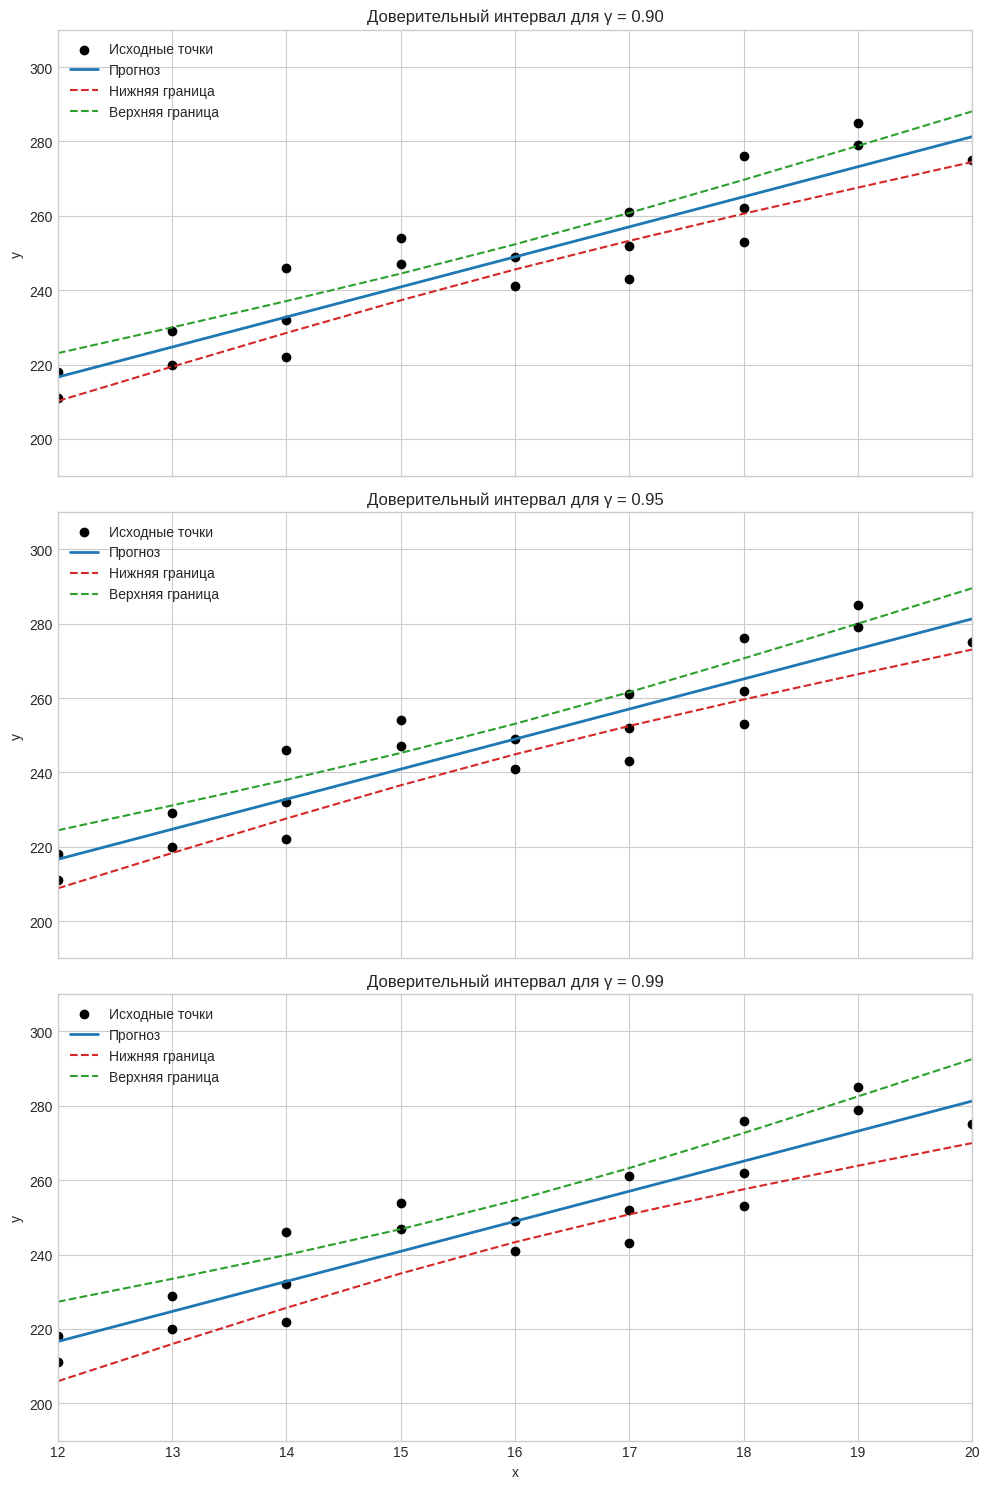

In [4]:
x_pred = np.arange(12, 21, dtype=float)
y_pred = a0 + a1 * x_pred
se_mean = np.sqrt(mse * (1 / n + (x_pred - mean_x) ** 2 / sxx))

forecast_rows = []
for gamma in [0.90, 0.95, 0.99]:
    alpha = 1 - gamma
    tcrit = stats.t.ppf(1 - alpha / 2, n - 2)
    lower = y_pred - tcrit * se_mean
    upper = y_pred + tcrit * se_mean
    for x_val, y_val, lo, up in zip(x_pred, y_pred, lower, upper):
        forecast_rows.append({
            'gamma': gamma,
            'x_pred': x_val,
            'y_pred': y_val,
            'lower': lo,
            'upper': up,
        })

forecasts = pd.DataFrame(forecast_rows)

fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True, sharey=True)
for ax, gamma in zip(axes, [0.90, 0.95, 0.99]):
    alpha = 1 - gamma
    tcrit = stats.t.ppf(1 - alpha / 2, n - 2)
    lower = y_pred - tcrit * se_mean
    upper = y_pred + tcrit * se_mean
    ax.scatter(x, y, color='black', label='Исходные точки')
    ax.plot(x_pred, y_pred, color='#1f77b4', linewidth=2, label='Прогноз')
    ax.plot(x_pred, lower, color='#d62728', linestyle='--', label='Нижняя граница')
    ax.plot(x_pred, upper, color='#2ca02c', linestyle='--', label='Верхняя граница')
    ax.set_title(f'Доверительный интервал для γ = {gamma:.2f}')
    ax.set_xlim(12, 20)
    ax.set_ylim(190, 310)
    ax.set_ylabel('y')
    ax.legend(loc='best')

axes[-1].set_xlabel('x')
plt.tight_layout()

forecasts

## Анализ остатков

Проверяем, что остатки не показывают систематического тренда, и оцениваем нормальность по гистограмме и тесту Шапиро-Уилка.

Тест Шапиро-Уилка: W = 0.9553, p-value = 0.4555


,t,x_t,y_t,y_hat_t,e_t
0,1,14.0,222.0,232.804531,-10.804531
1,2,16.0,241.0,248.961795,-7.961795
2,3,17.0,243.0,257.040426,-14.040426
3,4,19.0,285.0,273.197690,11.802310
4,5,18.0,253.0,265.119058,-12.119058
5,6,15.0,247.0,240.883163,6.116837
6,7,14.0,246.0,232.804531,13.195469
7,8,18.0,276.0,265.119058,10.880942
8,9,17.0,261.0,257.040426,3.959574
9,10,15.0,254.0,240.883163,13.116837


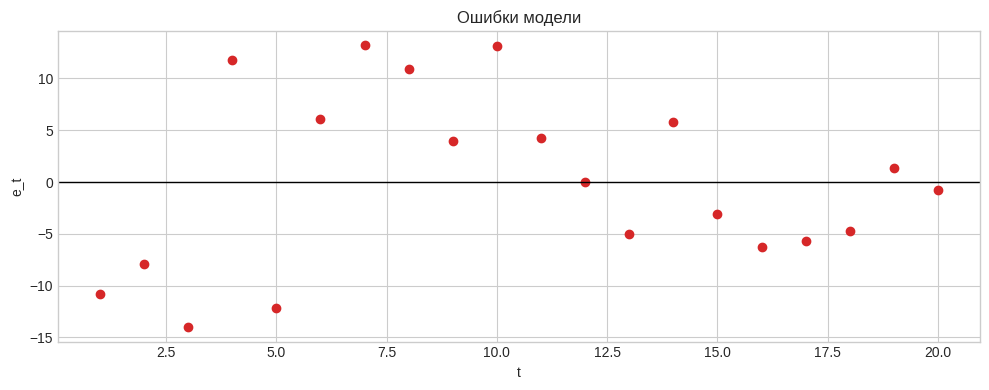

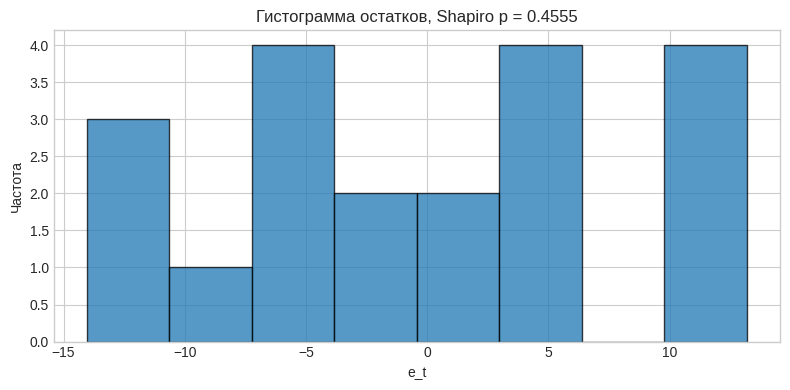

In [5]:
shapiro_stat, shapiro_p = stats.shapiro(residuals)

residuals_df = pd.DataFrame({
    't': np.arange(1, n + 1),
    'x_t': x,
    'y_t': y,
    'y_hat_t': y_hat,
    'e_t': residuals,
})

fig, ax = plt.subplots(figsize=(10, 4))
ax.axhline(0, color='black', linewidth=1)
ax.scatter(residuals_df['t'], residuals_df['e_t'], color='#d62728')
ax.set_xlabel('t')
ax.set_ylabel('e_t')
ax.set_title('Ошибки модели')
plt.tight_layout()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuals, bins=8, edgecolor='black', color='#1f77b4', alpha=0.75)
ax.set_title(f'Гистограмма остатков, Shapiro p = {shapiro_p:.4f}')
ax.set_xlabel('e_t')
ax.set_ylabel('Частота')
plt.tight_layout()

print(f'Тест Шапиро-Уилка: W = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}')
residuals_df

## Вывод

Модель имеет положительный наклон, высокий коэффициент детерминации и статистически значимые параметры при стандартных уровнях доверия. По остаткам нет заметного систематического тренда, а визуально их распределение близко к симметричному.